# Robot sensei

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# โหลดภาพที่ต้องการ

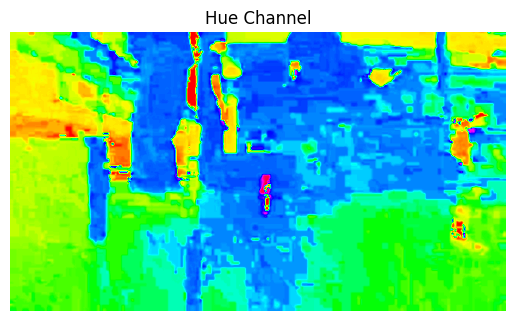

In [6]:
img = cv2.imread("captured_image_3.jpg")  #โหลดภาพ
image_hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
h,s,v=cv2.split(image_hsv) #แยกHSV เป็น hue saturation value
h_blur = cv2.GaussianBlur(h, (7, 7), 0) #เลือกh มาเบลอเพื่อลดnoise
plt.imshow(h_blur,cmap='hsv')
plt.title('Hue Channel')
plt.axis('off')
plt.show()  #แสดงผล

# ทำให้เป็น binary

Text(0.5, 1.0, 'Binary Image')

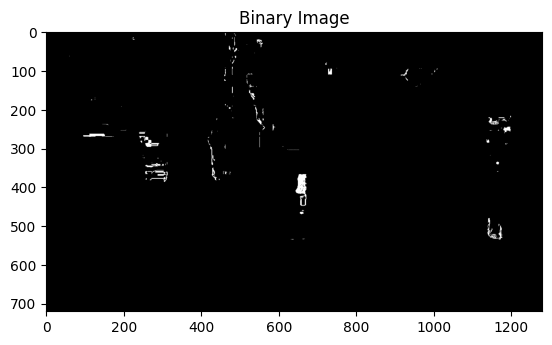

In [7]:
img_binary = ((h > 0) & (h < 10)) | ((h > 140) & (h < 180)) #ทำเป็นbinary โดยกำหนดสีที่ต้องการเป็นสีแดง
plt.imshow(img_binary, cmap='gray') #สีที่ตรงเงื่อนไขเป็นสีขาว ถ้าไม่เป็นสีดำ
plt.title('Binary Image') #แสดงผล

# โหลด bounding box(mask) 

Text(0.5, 1.0, 'Binary Image')

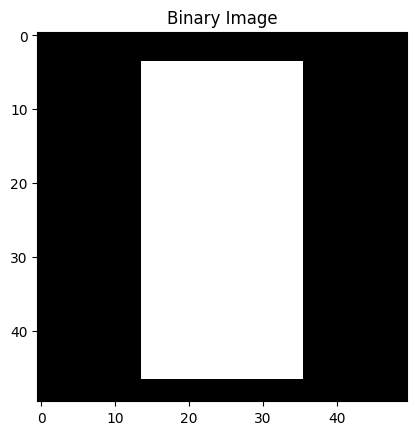

In [8]:
templat1=cv2.imread("bounding_box_1.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat1,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_1=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary1 = (template_v_1 > 100) #สร้างmask
plt.imshow(template_binary1, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

templat2=cv2.imread("bounding_box_2.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat2,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_2=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary2 = (template_v_2 > 100) #สร้างmask
plt.imshow(template_binary2, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

templat3=cv2.imread("bounding_box_3.jpg") #โหลดภาพ
template_hsv=cv2.cvtColor(templat3,cv2.COLOR_BGR2HSV) #แปลงเป็นHSV
template_h,template_s,template_v_3=cv2.split(template_hsv) #แยกHSV เป็น hue saturation value
template_binary3 = (template_v_3 > 100) #สร้างmask
plt.imshow(template_binary3, cmap='gray') #แสดงgrayscale
plt.title('Binary Image') #แสดงผล

# เลือกtemplateที่ตรงกันที่สุด และแสดงผล


Text(0.5, 1.0, 'Binary Image')

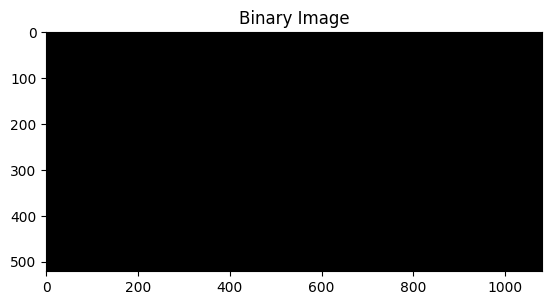

In [ ]:
#เปลี่ยนเป็น uint8 เพื่อให้ สามารถใช้ cv2.matchTemplate ได้ โดยการ*255เพื่อปรับให้ 0(ขาว),255(ดำ) 
img_binary_uint8 = img_binary.astype(np.uint8) * 255
template_binary_uint8_1 = template_binary1.astype(np.uint8) * 255
template_binary_uint8_2 = template_binary2.astype(np.uint8) * 255
template_binary_uint8_3 = template_binary3.astype(np.uint8) * 255
#จับคู่ภาพกับtemplate โดยเลือกtemplate
value = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_1, cv2.TM_CCOEFF_NORMED)
value2 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_2, cv2.TM_CCOEFF_NORMED)
value3 = cv2.matchTemplate(img_binary_uint8, template_binary_uint8_3, cv2.TM_CCOEFF_NORMED)
#กำหนดthresholdที่0.5 โดยยิ่งใกล้ 1 ยิ่งตรงกันมาก    
img_binary_va1 = (value > 0.5)
img_binary_va2 = (value2 > 0.5)
img_binary_va3 = (value3 > 0.5)
#แสดงผล
plt.imshow(img_binary_va1, cmap='gray')
plt.title('Binary Image')

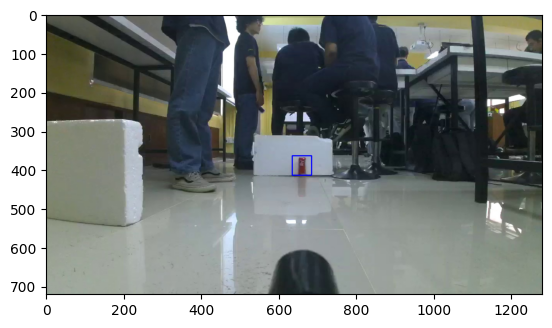

0.8229969143867493


In [ ]:
#หาค่าสูงสุดของแต่ละสเกล
min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(value)
min_val2, max_val2, min_loc2, max_loc2 = cv2.minMaxLoc(value2)
min_val3, max_val3, min_loc3, max_loc3 = cv2.minMaxLoc(value3)
#เลือกtemplateที่ตรงกันมากที่สุดมาแสดงผล
if max(max_val, max_val2, max_val3) == max_val:
    top_left = max_loc
    template_h, template_w = template_binary_uint8_1.shape
    max_val = max_val
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
elif max(max_val, max_val2, max_val3) == max_val2:
    top_left = max_loc2
    template_h, template_w = template_binary_uint8_2.shape
    max_val = max_val2
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
else:
    top_left = max_loc3
    template_h, template_w = template_binary_uint8_3.shape
    max_val = max_val3
    bottom_right = (top_left[0] + template_w, top_left[1] + template_h)
cv2.rectangle(img, top_left, bottom_right, 255, 2) # วาดกรอบ
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB)) # แสดงผล
plt.show()
print(max_val) # แสดงค่าที่ตรงกันมากที่สุด
